In [21]:
import time
import importlib
import cv2
import numpy as np
from ugot import ugot
import pose_yolo
importlib.reload(pose_yolo)
from pose_yolo import run_pose_control_inline
from IPython.display import display, clear_output, Image

got = ugot.UGOT()
got.initialize("192.168.1.215")

got.load_models(['word_recognition', 'color_recognition',
                 'line_recognition', 'face_recognition', 'apriltag_qrcode'])

got.set_track_recognition_line(0)

got.open_camera()

print("Done!")

192.168.1.215:50051
Done!


### Inbuilt UGOT models

- Line following
- Color recognition
- Text recognition
- Face recognition
- Apriltag / QR code

In [ ]:
def line_follow(mult=0.25, speed=20):
    offset, type, x, y = got.get_single_track_total_info()
    rotation_speed = int(offset * mult)
    print(offset, end = "             \r")

    got.mecanum_move_xyz(x_speed=0, y_speed=speed, z_speed=rotation_speed)

    return type, x, y

def color_rec():
    color_info = got.get_color_total_info()

    frame = got.read_camera_data()
    if frame is not None:
        nparr = np.frombuffer(frame, np.uint8)
        data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if color_info[0]:
            cv2.putText(data, color_info[0], (50, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

            c_x = color_info[2]
            c_y = color_info[3]
            h = color_info[4]
            w = color_info[5]

            cv2.rectangle(data, (int(c_x - w / 2), int(c_y - h / 2)), 
                            (int(c_x + w / 2), int(c_y + h / 2)), (0, 0, 255), 2)
            

        _, jpeg = cv2.imencode('.jpg', data)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        return color_info[0]


def text_rec():
    text = got.get_words_result()

    frame = got.read_camera_data()
    if frame is not None:
        nparr = np.frombuffer(frame, np.uint8)
        data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if text:
            cv2.putText(data, text, (50, 40), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        _, jpeg = cv2.imencode('.jpg', data)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

        return text


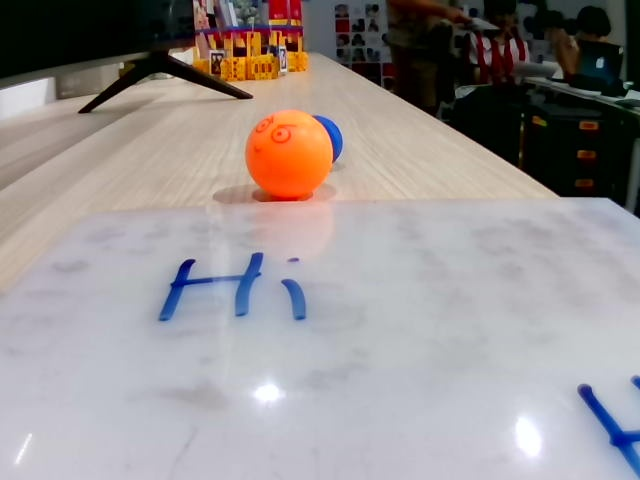

In [ ]:
while True:
    try:
        type, x, y = line_follow(mult = 0.4, speed = 30)
        # color = color_rec()
        # print(color, end = "      \r")
        # text = text_rec()
        # print(text, end="       \r")

    except KeyboardInterrupt:
        break


In [26]:
print(got.face_recognition_get_all_names())

got.face_recognition_add_name("michelle")
got.play_audio_tts("added", wait=True)
time.sleep(1)

# faces = got.face_recognition_get_all_names()
# for face in faces:
#     got.face_recognition_delete_name(face)

try:
    while True:
        faces = got.get_face_recognition_total_info()
        print('-:',faces, end="                                                   \r")
        if faces:
            got.play_audio_tts(faces[0][0], wait=True)
        time.sleep(0.5)
except KeyboardInterrupt:
    pass

['Michael', 'abhiraam', 'rickase', 'RICKS', 'Object', 'Li', 'patrick', 'yang xu', 'Andrew', 'Agrim', 'haz', 'kayden', 'Tingyou', 'Patrick', 'sigma69', 'vesyiog', 'a', 'nj', 'u', 'gaydeer', 'Markers', 'verylong', 'hand', 'onefish', 'morty', 'Ryan', 'ben', 'aobama', 'pascal']


3 seconds until taking a photo
2 seconds until taking a photo
1 seconds until taking a photo
Taking a photo...
Face [michelle] registered successfully



In [14]:
# Helper functions: pick up token
def ap_approach():
    got.load_models(["apriltag_qrcode"])
    # approach apriltag to pick it up
    while True:
        AP_info = got.get_apriltag_total_info()
        if AP_info:
            x_coord = AP_info[0][1]
            dist = AP_info[0][6]
            if x_coord < 290:
                 got.mecanum_move_xyz(-3, 3, 0)
            elif x_coord > 350:
                got.mecanum_move_xyz(3, 3, 0)
            elif dist > 0.12:
                got.mecanum_move_xyz(0, 3, 0)
            else:
                got.mecanum_stop()
                break
        else:
            got.mecanum_stop()
    print("Stopped.")

def pickup_ap():
    got.mechanical_clamp_release()
    time.sleep(1)
    got.mechanical_joint_control(0, 0, -70, 800) #down - for apriltag
    time.sleep(1)
    got.mechanical_clamp_close()
    time.sleep(2)
    got.mechanical_joint_control(0, 60, -50, 800) #up

def put_ap():
    got.mechanical_joint_control(-90, 30, -50, 800)
    time.sleep(1)
    got.mechanical_joint_control(-90, -20, -30, 800)
    time.sleep(1)
    got.mechanical_clamp_release()
    time.sleep(2)

got.mechanical_joint_control(80, 30, 30, 1000)
ap_approach()
pickup_ap()
got.mecanum_move_speed_times(0, 30, 30, 1)
put_ap()

Stopped.


# Pose control

Located in a separate .py file!

In [ ]:
# try:
#     run_pose_control_inline(
#     robot_ip='192.168.1.217',
#     forward_speed=30,
#     backward_speed=30,
#     turn_speed=45,
#     camera_index=0,
#     model_path="yolov8n-pose.pt",
#     up_margin_factor=0.6,
#     down_margin_factor=0.6,
#     min_conf=0.3,
#     enable_robot=False,
#     debounce_frames=2,
#     max_frames=None)

# except KeyboardInterrupt:
#     print("Done")

# Sample

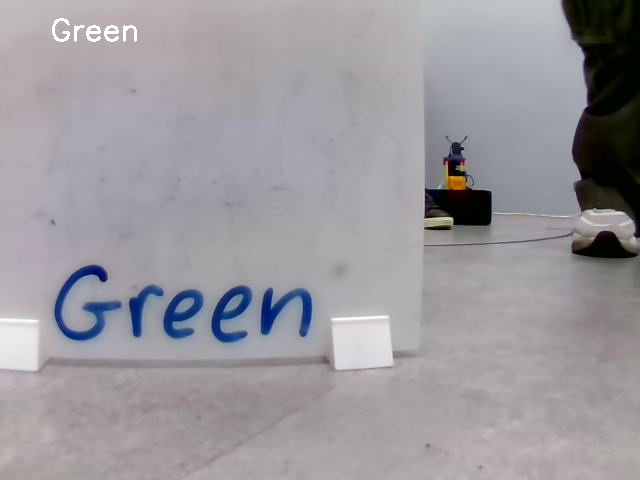

Done


In [ ]:
try:
    # Initial values
    got.screen_display_background(0)
    got.mechanical_joint_control(0, 45, 45, 500)

    #ap_approach()
    #got.mecanum_move_speed_times(0, 3, 3, 1)
    #pickup_ap()
    #time.sleep(1)
    #got.mecanum_move_speed_times(0, 20, 5, 1)

    # # pose control
    # run_pose_control_inline(
    # up_margin_factor=0.7,
    # down_margin_factor=0.7,
    # debounce_frames=2,
    # got=got
    # )

    # Stop light
    while True:
        color = color_rec()

        if color == "Purple":
            got.screen_display_background(2)
        elif color == "Blue":
            got.screen_display_background(8)
        elif color == "Green":
            got.screen_display_background(6)
            time.sleep(1)
            break
        else:
            got.screen_display_background(0)


    # Street signs
    crossroads = 0
    seen_alexis = False
    seen_ben = False
    seen_cora = False

    while crossroads < 2:
        # display image
        frame = got.read_camera_data()
        if frame is not None:
            nparr = np.frombuffer(frame, np.uint8)
            data = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
            _, jpeg = cv2.imencode('.jpg', data)
            clear_output(wait=True)
            display(Image(data=jpeg.tobytes()))
            
        # follow line
        line_type, x, y = line_follow(mult=0.25, speed=18)
        face_result = got.get_face_recognition_total_info()
        if face_result:
            face = face_result[0][0]
            if (not seen_alexis and face=="alexis") or\
                (not seen_ben and face=="ben") or\
                (not seen_cora and face=="cora"):
                got.mecanum_stop()
                got.play_audio_tts(face, wait=True)
                got.screen_print_text_newline(face, 1)
                
                if face == "alexis":
                    seen_alexis = True
                    got.screen_display_background(2)
                elif face == "ben":
                    seen_ben = True
                    got.screen_display_background(3)
                elif face == "cora":
                    seen_cora = True
                    got.screen_display_background(4)
                time.sleep(2)
                got.screen_display_background(0)
        
        if line_type == 3:# and y > 380:
            crossroads += 1
            got.mecanum_move_speed_times(0, 20, 15, 1)
            got.mecanum_turn_speed_times(2, 70, 90, 2)
            time.sleep(0.5)
            text = text_rec()
            if "Red" in text:
                got.screen_display_background(3)
                time.sleep(2)
                # got.mecanum_turn_speed_times(3, 70, 180, 2)
            elif "Green" in text:
                got.screen_display_background(6)
                time.sleep(2)
                # got.mecanum_turn_speed_times(3, 70, 180, 2)
            
            got.mecanum_turn_speed_times(3, 70, 90, 2)

    got.mecanum_turn_speed_times(3, 60, 30, 2)
    got.screen_display_background(4)
    time.sleep(1)


    got.mecanum_move_speed_times(0, 20, 20, 1)

finally:
    got.mecanum_stop()
    put_ap()
    print("Done")